In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
raw_data = pd.read_csv("data/311_Service_Requests_from_2020_to_Present_20260224.csv")
raw_data.head()

/var/folders/pr/0jl9zy5j5nvcs0ycl3xdjjmm0000gn/T/ipykernel_56916/2377323264.py:1: DtypeWarning: Columns (12,13,14,15,18) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv("data/311_Service_Requests_from_2020_to_Present_20260224.csv")


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,68079492,02/22/2026 11:57:17 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HEAT AND NO HOT WATER,RESIDENTIAL BUILDING,10016.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.742783,-73.982342,POINT (-73.98234229858 40.742783051746)
1,68079529,02/22/2026 11:57:16 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,10456.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.826908,-73.909060,POINT (-73.909059685455 40.826907556946)
2,68071879,02/22/2026 11:55:12 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HEAT,RESIDENTIAL BUILDING,10466.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.889346,-73.864004,POINT (-73.864003882066 40.889346397138)
3,68077244,02/22/2026 11:54:19 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HEAT,RESIDENTIAL BUILDING,10469.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.863991,-73.859670,POINT (-73.85967031412 40.863991210716)
4,68075064,02/22/2026 11:54:16 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HEAT,RESIDENTIAL BUILDING,11435.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.705784,-73.809588,POINT (-73.809587909022 40.705784035042)


In [3]:
raw_data.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Problem (formerly Complaint Type)',
       'Problem Detail (formerly Descriptor)', 'Additional Details',
       'Location Type', 'Incident Zip', 'Incident Address', 'Street Name',
       'Cross Street 1', 'Cross Street 2', 'Intersection Street 1',
       'Intersection Street 2', 'Address Type', 'City', 'Landmark',
       'Facility Type', 'Status', 'Due Date', 'Resolution Description',
       'Resolution Action Updated Date', 'Community Board', 'Council District',
       'Police Precinct', 'BBL', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Open Data Channel Type',
       'Park Facility Name', 'Park Borough', 'Vehicle Type',
       'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name',
       'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment',
       'Latitude', 'Longitude', 'Location'],
      dtype='object')

#### Drop columns

In [4]:
# drop columns
cols_to_drop = [
    "Agency", "Agency Name",
    "Problem (formerly Complaint Type)",
    "Location Type", "Cross Street 1", "Cross Street 2", "Intersection Street 1", "Intersection Street 2", "Address Type",
    "City", "Landmark", "Facility Type",
    "Status",
    "Due Date",
    "Resolution Action Updated Date",
    "Community Board", "Police Precinct", "BBL",
    "X Coordinate (State Plane)", "Y Coordinate (State Plane)", "Open Data Channel Type",
    "Park Facility Name", "Park Borough",
    "Vehicle Type", "Taxi Company Borough", "Taxi Pick Up Location",
    "Bridge Highway Name", "Bridge Highway Direction", "Road Ramp", "Bridge Highway Segment",
    "Latitude", "Longitude", "Location"
]
proc_data = raw_data.copy()
proc_data.drop(columns=cols_to_drop, inplace=True)

In [5]:
proc_data.columns

Index(['Unique Key', 'Created Date', 'Closed Date',
       'Problem Detail (formerly Descriptor)', 'Additional Details',
       'Incident Zip', 'Incident Address', 'Street Name',
       'Resolution Description', 'Council District', 'Borough'],
      dtype='object')

#### Preprocess columns

In [6]:
# problem detail -- entire building / apartment only
proc_data["Problem Detail (formerly Descriptor)"].unique()

array(['ENTIRE BUILDING', 'APARTMENT ONLY', 'Entire Building',
       'Apartment Only', 'Water Supply'], dtype=object)

<Axes: xlabel='Problem Detail (formerly Descriptor)'>

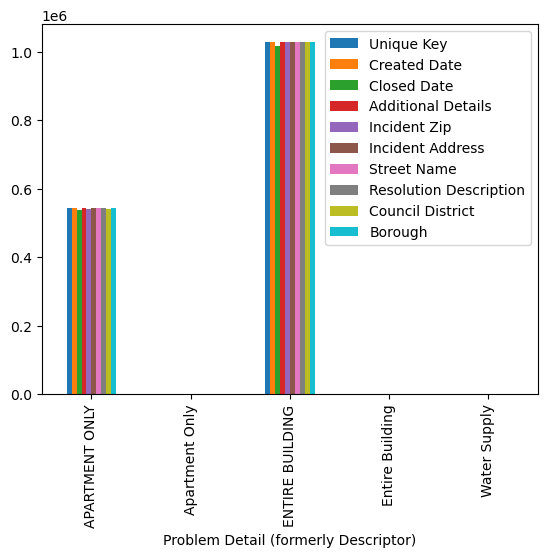

In [7]:
proc_data.groupby(by="Problem Detail (formerly Descriptor)").count().plot.bar()

In [8]:
# One-hot encode Problem Detail column
proc_data['Apartment_Only'] = (proc_data['Problem Detail (formerly Descriptor)'] == 'APARTMENT ONLY').astype(int)
proc_data['Entire_Building'] = (proc_data['Problem Detail (formerly Descriptor)'] == 'ENTIRE BUILDING').astype(int)

# Drop original column
proc_data.drop(columns=['Problem Detail (formerly Descriptor)'], inplace=True)

# Verify encoding
print("One-hot encoding complete:")
print(f"Apartment_Only: {proc_data['Apartment_Only'].sum()} records")
print(f"Entire_Building: {proc_data['Entire_Building'].sum()} records")

One-hot encoding complete:
Apartment_Only: 541913 records
Entire_Building: 1027635 records


In [9]:
# One-hot encode Additional Details column
proc_data['No_Heat_No_Hot_Water'] = (proc_data['Additional Details'] == 'NO HEAT AND NO HOT WATER').astype(int)
proc_data['No_Heat'] = (proc_data['Additional Details'] == 'NO HEAT').astype(int)
proc_data['No_Hot_Water'] = (proc_data['Additional Details'] == 'NO HOT WATER').astype(int)

# Drop original column
proc_data.drop(columns=['Additional Details'], inplace=True)

# Verify encoding
print("One-hot encoding complete for Additional Details:")
print(f"No_Heat_No_Hot_Water: {proc_data['No_Heat_No_Hot_Water'].sum()} records")
print(f"No_Heat: {proc_data['No_Heat'].sum()} records")
print(f"No_Hot_Water: {proc_data['No_Hot_Water'].sum()} records")

One-hot encoding complete for Additional Details:
No_Heat_No_Hot_Water: 407379 records
No_Heat: 925121 records
No_Hot_Water: 232355 records


In [10]:
# resolution
proc_data["Resolution Description"].unique()

array(['The following complaint conditions are still open. HPD has already attempted to notify the property owner that the condition exists; the tenant should provide access for the owner to make the repair.  HPD may attempt to contact the tenant by phone to verify the correction of the condition or an HPD Inspector may attempt to conduct an inspection.',
       'This complaint is a duplicate of a building-wide condition already reported by another tenant.  The original complaint is still open, and HPD may only need to confirm that the condition exists by inspecting one apartment.  If we cannot contact the tenant from the original complaint or get access to that apartment, HPD may attempt to contact the person who filed this complaint to verify the correction of the condition or may conduct an inspection of your unit. You can check HPDONLINE to see if a',
       "The Department of Housing Preservation and Development conducted or attempted to conduct an inspection.  More information ab

In [11]:
# Analyze most common resolution descriptions
print("=== RESOLUTION DESCRIPTION ANALYSIS ===\n")

# Get value counts
resolution_counts = proc_data['Resolution Description'].value_counts()
print(f"Total unique resolutions: {len(resolution_counts)}\n")

# Show top 15 most common resolutions
print("Top 15 Most Common Resolutions:\n")
for idx, (resolution, count) in enumerate(resolution_counts.head(15).items(), 1):
    percentage = (count / len(proc_data)) * 100
    print(f"{idx}. [{percentage:5.2f}%] {count:7d} cases - {resolution}")

# Summary statistics
print(f"\n=== SUMMARY ===")
print(f"Total records: {len(proc_data)}")
print(f"Most common resolution: {resolution_counts.index[0]}")
print(f"Frequency of most common: {resolution_counts.iloc[0]} ({(resolution_counts.iloc[0]/len(proc_data)*100):.2f}%)")
print(f"Top 5 resolutions account for {(resolution_counts.head(5).sum()/len(proc_data)*100):.2f}% of all cases")

=== RESOLUTION DESCRIPTION ANALYSIS ===

Total unique resolutions: 39

Top 15 Most Common Resolutions:

1. [17.44%]  274040 cases - The complaint you filed is a duplicate of a condition already reported by another tenant for a building-wide condition. The original complaint is still open. HPD may attempt to contact you to verify the correction of the condition or may conduct an inspection of your unit if the original complainant is not available for verification.
2. [14.13%]  222071 cases - The Department of Housing Preservation and Development was not able to gain access to your apartment or others in the building to inspect for a lack of heat or hot water. The complaint has been closed. If the condition still exists, please file a new complaint.
3. [12.30%]  193308 cases - The Department of Housing Preservation and Development responded to a complaint of no heat or hot water and was advised by a tenant in the building that heat and hot water had been restored. If the condition still 

In [12]:
# Create binary column for no access cases
proc_data['No_Access'] = proc_data['Resolution Description'].str.contains(
    'not able to gain access', 
    case=False, 
    na=False
).astype(int)

# Verify the encoding
print("No_Access encoding complete:")
print(f"Cases with no access: {proc_data['No_Access'].sum()} records")
print(f"Cases with access: {(proc_data['No_Access'] == 0).sum()} records")
print(f"\nSample of 'no access' cases:")
print(proc_data[proc_data['No_Access'] == 1]['Resolution Description'].head())

No_Access encoding complete:
Cases with no access: 235840 records
Cases with access: 1335522 records

Sample of 'no access' cases:
1618    The Department of Housing Preservation and Dev...
2129    The Department of Housing Preservation and Dev...
2304    The Department of Housing Preservation and Dev...
2473    The Department of Housing Preservation and Dev...
2503    The Department of Housing Preservation and Dev...
Name: Resolution Description, dtype: object


In [13]:
# Create binary column for no violation issued cases
proc_data['No_Violation_Issued'] = (
    proc_data['Resolution Description'].str.contains(
    'No violations were issued', 
    case=False, 
    na=False
    ) | 
    proc_data['Resolution Description'].str.contains(
    'did not violate the housing laws', 
    case=False, 
    na=False
    )
).astype(int)

# Verify the encoding
print("No_Violation_Issued encoding complete:")
print(f"Cases with no violation issued: {proc_data['No_Violation_Issued'].sum()} records")
print(f"Cases with violations issued: {(proc_data['No_Violation_Issued'] == 0).sum()} records")
print(f"\nSample of 'no violation issued' cases:")
print(proc_data[proc_data['No_Violation_Issued'] == 1]['Resolution Description'].head())

No_Violation_Issued encoding complete:
Cases with no violation issued: 122446 records
Cases with violations issued: 1448916 records

Sample of 'no violation issued' cases:
2253    HPD conducted an inspection of this complaint....
2310    HPD conducted an inspection of this complaint....
2522    HPD conducted an inspection of this complaint....
2559    HPD conducted an inspection of this complaint....
2723    HPD conducted an inspection of this complaint....
Name: Resolution Description, dtype: object


In [14]:
# Create binary column for no violation issued cases
proc_data['Violation_Issued'] = proc_data['Resolution Description'].str.contains(
    'Violations were issued', 
    case=False, 
    na=False
).astype(int)

# Verify the encoding
print("Violation_Issued encoding complete:")
print(f"Cases with violation issued: {proc_data['Violation_Issued'].sum()} records")
print(f"Cases with no violations issued: {(proc_data['Violation_Issued'] == 0).sum()} records")
print(f"Percentage : {(proc_data['Violation_Issued'].sum() / len(proc_data) * 100):.2f}%")
print(f"\nSample of 'violation issued' cases:")
print(proc_data[proc_data['Violation_Issued'] == 1]['Resolution Description'].head())

Violation_Issued encoding complete:
Cases with violation issued: 150937 records
Cases with no violations issued: 1420425 records
Percentage : 9.61%

Sample of 'violation issued' cases:
2392    HPD inspected this condition so the complaint ...
2917    HPD inspected this condition so the complaint ...
3139    HPD inspected this condition so the complaint ...
3192    HPD inspected this condition so the complaint ...
3208    HPD inspected this condition so the complaint ...
Name: Resolution Description, dtype: object


In [15]:
# Create binary column for duplicate cases
proc_data['Duplicate'] = proc_data['Resolution Description'].str.contains(
    'is a duplicate', 
    case=False, 
    na=False
).astype(int)

# Verify the encoding
print("Duplicate encoding complete:")
print(f"Cases marked as duplicate: {proc_data['Duplicate'].sum()} records")
print(f"Cases not marked as duplicate: {(proc_data['Duplicate'] == 0).sum()} records")
print(f"Percentage duplicates: {(proc_data['Duplicate'].sum() / len(proc_data) * 100):.2f}%")
print(f"\nSample of 'duplicate' cases:")
print(proc_data[proc_data['Duplicate'] == 1]['Resolution Description'].head())

Duplicate encoding complete:
Cases marked as duplicate: 441599 records
Cases not marked as duplicate: 1129763 records
Percentage duplicates: 28.10%

Sample of 'duplicate' cases:
3     This complaint is a duplicate of a building-wi...
4     This complaint is a duplicate of a building-wi...
7     This complaint is a duplicate of a building-wi...
9     This complaint is a duplicate of a building-wi...
10    This complaint is a duplicate of a building-wi...
Name: Resolution Description, dtype: object


In [16]:
# Create binary column for corrected cases
proc_data['Corrected'] = (
    proc_data['Resolution Description'].str.contains(
        'had been restored', 
        case=False, 
        na=False
    ) | 
    proc_data['Resolution Description'].str.contains(
        'conditions were corrected', 
        case=False, 
        na=False
    )
).astype(int)

# Verify the encoding
print("Corrected encoding complete:")
print(f"Cases marked as corrected: {proc_data['Corrected'].sum()} records")
print(f"Cases not marked as corrected: {(proc_data['Corrected'] == 0).sum()} records")
print(f"Percentage corrected: {(proc_data['Corrected'].sum() / len(proc_data) * 100):.2f}%")
print(f"\nSample of 'corrected' cases:")
print(proc_data[proc_data['Corrected'] == 1]['Resolution Description'].head())

Corrected encoding complete:
Cases marked as corrected: 498121 records
Cases not marked as corrected: 1073241 records
Percentage corrected: 31.70%

Sample of 'corrected' cases:
953     HPD responded to a complaint of no heat or hot...
1034    HPD responded to a complaint of no heat or hot...
1344    HPD responded to a complaint of no heat or hot...
2130    HPD responded to a complaint of no heat or hot...
2248    HPD responded to a complaint of no heat or hot...
Name: Resolution Description, dtype: object


In [17]:
# Breakdown of resolution categories
print("=== RESOLUTION CATEGORY BREAKDOWN ===\n")

categories = {
    'Duplicate': proc_data['Duplicate'],
    'No_Access': proc_data['No_Access'],
    'No_Violation_Issued': proc_data['No_Violation_Issued'],
    'Violation_Issued': proc_data['Violation_Issued'],
    'Corrected': proc_data['Corrected']
}

total_records = len(proc_data)

# Calculate and display percentages
for category_name, category_data in categories.items():
    count = category_data.sum()
    percentage = (count / total_records) * 100
    print(f"{category_name:25s}: {count:8d} records ({percentage:6.2f}%)")

print(f"\n{'Total records':25s}: {total_records:8d}")
print(f"\nNote: Categories may overlap - a single report can belong to multiple categories")

=== RESOLUTION CATEGORY BREAKDOWN ===

Duplicate                :   441599 records ( 28.10%)
No_Access                :   235840 records ( 15.01%)
No_Violation_Issued      :   122446 records (  7.79%)
Violation_Issued         :   150937 records (  9.61%)
Corrected                :   498121 records ( 31.70%)

Total records            :  1571362

Note: Categories may overlap - a single report can belong to multiple categories


/var/folders/pr/0jl9zy5j5nvcs0ycl3xdjjmm0000gn/T/ipykernel_56916/2147087472.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  proc_data['Created Date'] = pd.to_datetime(proc_data['Created Date'])
/var/folders/pr/0jl9zy5j5nvcs0ycl3xdjjmm0000gn/T/ipykernel_56916/2147087472.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  proc_data['Closed Date'] = pd.to_datetime(proc_data['Closed Date'])


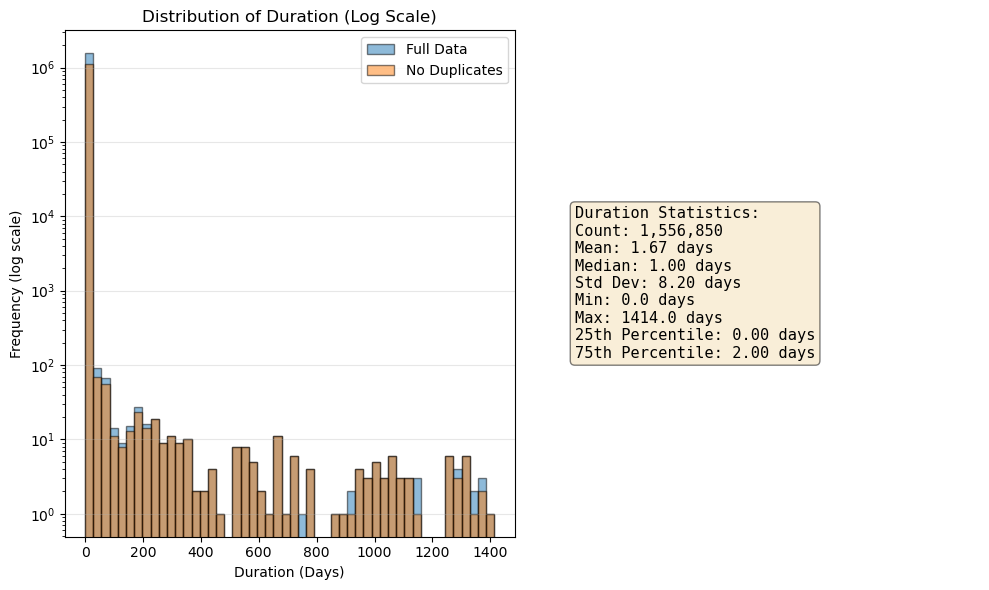


Duration Analysis Summary:
Total records with closed dates: 1,556,850
Records excluded (missing closure date or negative duration): 14,512


In [18]:
# Calculate duration between Created Date and Closed Date
proc_data['Created Date'] = pd.to_datetime(proc_data['Created Date'])
proc_data['Closed Date'] = pd.to_datetime(proc_data['Closed Date'])

# Calculate duration in days
proc_data['Duration_Days'] = (proc_data['Closed Date'] - proc_data['Created Date']).dt.days

# Remove records with missing Closed Date or negative duration
proc_data_no_dupl = proc_data[proc_data["Duplicate"]==0].copy()
duration_clean_no_dupl = proc_data_no_dupl[proc_data_no_dupl['Closed Date'].notna() & (proc_data_no_dupl['Duration_Days'] >= 0)]['Duration_Days']
duration_clean = proc_data[proc_data['Closed Date'].notna() & (proc_data['Duration_Days'] >= 0)]['Duration_Days']

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Log scale histogram (to better see distribution with outliers)
axes[0].hist(duration_clean, bins=50, edgecolor='black', alpha=0.5,label="Full Data")
axes[0].hist(duration_clean_no_dupl, bins=50, edgecolor='black', alpha=0.5, label="No Duplicates")
axes[0].set_xlabel('Duration (Days)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_yscale('log')
axes[0].set_title('Distribution of Duration (Log Scale)')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# 4. Statistics text
stats_text = f"""Duration Statistics:
Count: {len(duration_clean):,}
Mean: {duration_clean.mean():.2f} days
Median: {duration_clean.median():.2f} days
Std Dev: {duration_clean.std():.2f} days
Min: {duration_clean.min()} days
Max: {duration_clean.max()} days
25th Percentile: {duration_clean.quantile(0.25):.2f} days
75th Percentile: {duration_clean.quantile(0.75):.2f} days"""

axes[1].text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center',
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nDuration Analysis Summary:")
print(f"Total records with closed dates: {len(duration_clean):,}")
print(f"Records excluded (missing closure date or negative duration): {len(proc_data) - len(duration_clean):,}")


In [19]:
# Drop rows with missing Closed Date
proc_clean_data = proc_data.drop(index=np.where(proc_data["Closed Date"].isna())[0], inplace=False)

# Define resolution flag columns
resolution_flags = ['No_Access', 'Duplicate', 'Violation_Issued', 'No_Violation_Issued', 'Corrected']

# Ensure the columns exist (guard for earlier workflow differences)
missing_cols = [c for c in resolution_flags if c not in proc_clean_data.columns]
if missing_cols:
    raise KeyError(f"Missing expected resolution columns in proc_clean_data: {missing_cols}")

# Create mask for rows with NO resolution (all flags == 0)
no_resolution_mask = (proc_clean_data[resolution_flags].sum(axis=1) == 0)

# Counts before and after
before_count = len(proc_clean_data)
proc_clean_data = proc_clean_data.loc[~no_resolution_mask].copy()
after_count = len(proc_clean_data)

print(f"Dropped {before_count - after_count:,} rows with no resolution. Remaining: {after_count:,} rows.")

proc_clean_data

Dropped 198,277 rows with no resolution. Remaining: 1,358,757 rows.


,Unique Key,Created Date,Closed Date,Incident Zip,Incident Address,Street Name,Resolution Description,Council District,Borough,Apartment_Only,Entire_Building,No_Heat_No_Hot_Water,No_Heat,No_Hot_Water,No_Access,No_Violation_Issued,Violation_Issued,Duplicate,Corrected,Duration_Days
953,68077234,2026-02-22 14:53:30,2026-02-22 18:11:41,10031.0,617 WEST 141 STREET,WEST 141 STREET,HPD responded to a complaint of no heat or hot...,7.0,MANHATTAN,0,1,0,1,0,0,0,0,0,1,0.0
1034,68071869,2026-02-22 14:17:37,2026-02-22 18:23:31,10032.0,516 WEST 156 STREET,WEST 156 STREET,HPD responded to a complaint of no heat or hot...,10.0,MANHATTAN,0,1,0,1,0,0,0,0,0,1,0.0
1344,68072958,2026-02-22 11:26:59,2026-02-22 17:08:20,10023.0,141 WEST 73 STREET,WEST 73 STREET,HPD responded to a complaint of no heat or hot...,6.0,MANHATTAN,0,1,0,1,0,0,0,0,0,1,0.0
1618,68071976,2026-02-22 08:10:41,2026-02-22 17:29:54,10451.0,317 EAST 150 STREET,EAST 150 STREET,The Department of Housing Preservation and Dev...,17.0,BRONX,0,1,1,0,0,1,0,0,0,0,0.0
1922,68062080,2026-02-21 23:40:30,2026-02-22 17:15:30,10463.0,3605 SEDGWICK AVENUE,SEDGWICK AVENUE,This complaint is a duplicate of a building-wi...,11.0,BRONX,1,0,0,1,0,0,0,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571357,45289096,2020-01-01 00:15:59,2020-01-02 02:09:02,10452.0,11 WEST 172 STREET,WEST 172 STREET,The complaint you filed is a duplicate of a co...,14.0,BRONX,0,1,0,1,0,0,0,0,1,0,1.0
1571358,45285312,2020-01-01 00:13:46,2020-01-02 02:09:02,10452.0,11 WEST 172 STREET,WEST 172 STREET,The Department of Housing Preservation and Dev...,14.0,BRONX,0,1,0,1,0,1,0,0,0,0,1.0
1571359,45288483,2020-01-01 00:12:46,2020-01-03 15:33:19,10016.0,11 EAST 32 STREET,EAST 32 STREET,The Department of Housing Preservation and Dev...,4.0,MANHATTAN,0,1,0,1,0,0,0,0,0,1,2.0
1571360,45289521,2020-01-01 00:09:42,2020-01-02 06:16:46,10031.0,611 WEST 148 STREET,WEST 148 STREET,The complaint you filed is a duplicate of a co...,7.0,MANHATTAN,1,0,0,1,0,0,0,0,1,0,1.0


#### Transition Probabilities

In [20]:
len(proc_clean_data[proc_clean_data["No_Access"]==1])/len(proc_clean_data)

0.17357040294916604

In [21]:
len(proc_clean_data[proc_clean_data["Corrected"]==1])/len(proc_clean_data)

0.36660050325407706

In [22]:
len(proc_clean_data[proc_clean_data["No_Violation_Issued"]==1])/len(proc_clean_data)

0.09011177127330347

In [23]:
len(proc_clean_data[proc_clean_data["Violation_Issued"]==1])/len(proc_clean_data)

0.11107357680586007

In [24]:
len(proc_clean_data[proc_clean_data["Duplicate"]==1])/len(proc_clean_data)

0.32380845140080233

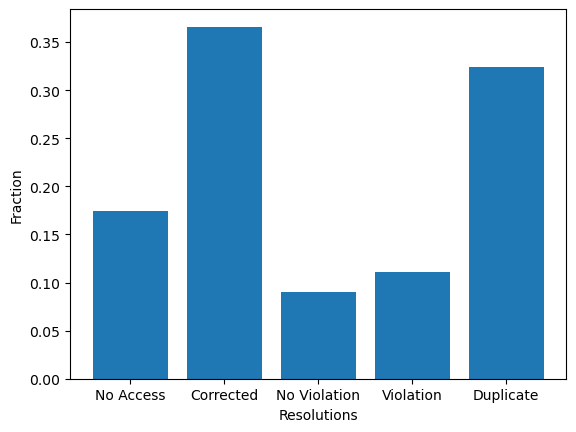

In [25]:
fig,axes = plt.subplots(1,1)
axes.bar(np.arange(5), [0.174, 0.366, 0.09, 0.111, 0.324])
axes.set_xticks(np.arange(5), ["No Access", "Corrected", "No Violation", "Violation", "Duplicate"])
axes.set_xlabel("Resolutions")
axes.set_ylabel("Fraction")
plt.show()

#### Case Volume

/var/folders/pr/0jl9zy5j5nvcs0ycl3xdjjmm0000gn/T/ipykernel_56916/2437047956.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = proc_clean_data.set_index('Created Date').resample('M').size()


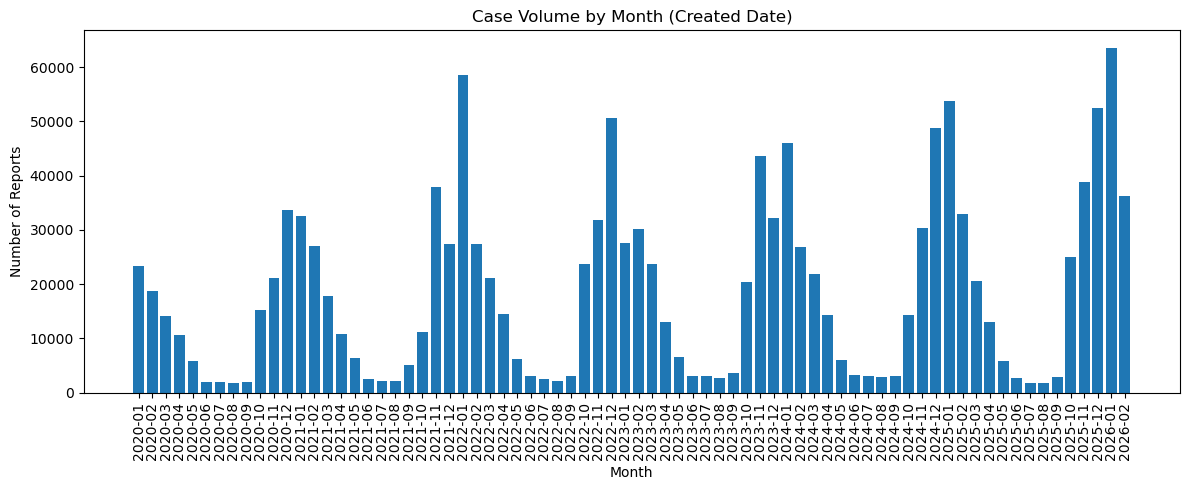

/var/folders/pr/0jl9zy5j5nvcs0ycl3xdjjmm0000gn/T/ipykernel_56916/2437047956.py:18: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_counts = proc_clean_data.set_index('Created Date').resample('Y').size()


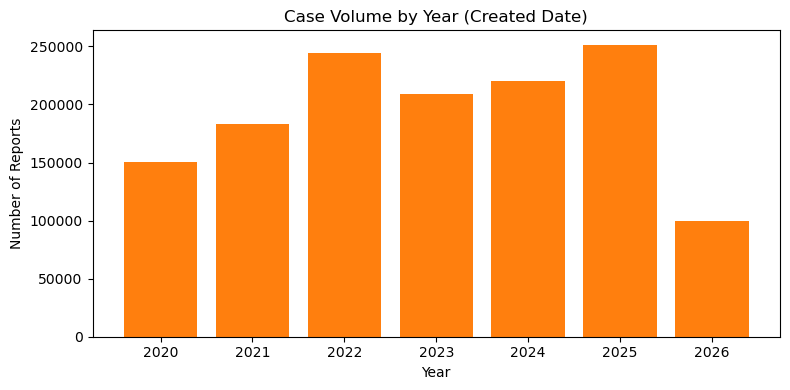

In [ ]:
# Plot case volume by month using Created Date
proc_clean_data['Created Date'] = pd.to_datetime(proc_clean_data['Created Date'], errors='coerce')

# Resample by month (end of month) and count reports
monthly_counts = proc_clean_data.set_index('Created Date').resample('M').size()

# Plot
plt.figure(figsize=(12,5))
plt.bar(monthly_counts.index.to_series().dt.strftime('%Y-%m'), monthly_counts.values, color='C0')
plt.xlabel('Month')
plt.ylabel('Number of Reports')
plt.title('Case Volume by Month (Created Date)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# yearly volume distribution based on Created Date
yearly_counts = proc_clean_data.set_index('Created Date').resample('Y').size()

plt.figure(figsize=(8,4))
plt.bar(yearly_counts.index.year.astype(str), yearly_counts.values, color='C1')
plt.xlabel('Year')
plt.ylabel('Number of Reports')
plt.title('Case Volume by Year (Created Date)')
plt.tight_layout()
plt.show()

In [34]:
proc_clean_data.describe()

,Unique Key,Created Date,Closed Date,Incident Zip,Council District,Apartment_Only,Entire_Building,No_Heat_No_Hot_Water,No_Heat,No_Hot_Water,No_Access,No_Violation_Issued,Violation_Issued,Duplicate,Corrected,Duration_Days
count,1.358757e+06,1358757,1358757,1.358596e+06,1.358596e+06,1.358757e+06,1.358757e+06,1.358757e+06,1.358757e+06,1.358757e+06,1.358757e+06,1.358757e+06,1.358757e+06,1.358757e+06,1.358757e+06,1.358757e+06
mean,5.796246e+07,2023-06-10 11:57:08.478096640,2023-06-12 17:51:52.333999104,1.069147e+04,2.165912e+01,3.387346e-01,6.612654e-01,2.556587e-01,5.927241e-01,1.484607e-01,1.735704e-01,9.011177e-02,1.110736e-01,3.238085e-01,3.666005e-01,1.756554e+00
min,4.528482e+07,2020-01-01 00:04:45,2020-01-02 02:08:45,1.000100e+04,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.298083e+07,2022-01-06 01:02:09,2022-01-09 09:03:10,1.045100e+04,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
50%,5.783053e+07,2023-06-07 10:01:19,2023-06-09 13:56:11,1.046700e+04,1.600000e+01,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,6.367530e+07,2025-01-07 20:58:48,2025-01-09 21:07:47,1.122000e+04,3.500000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
max,6.807723e+07,2026-02-22 14:53:30,2026-02-22 23:56:01,1.234500e+04,5.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.374000e+03
std,6.576590e+06,NaN,NaN,5.112176e+02,1.352842e+01,4.732797e-01,4.732797e-01,4.362310e-01,4.913272e-01,3.555562e-01,3.787398e-01,2.863419e-01,3.142233e-01,4.679281e-01,4.818763e-01,3.126754e+00


#### Save preprocessed data

In [27]:
proc_clean_data.to_csv("data/311_preproc.csv")